In [ ]:
import numpy as np

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
import pickle
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
import seaborn as sns

In [21]:
# EfficientNetB0 native resolution is 224x224
IMG_SIZE = 224

def load_dataset(base_path):
    X = []
    y = []
    class_names = sorted(os.listdir(base_path))
    for label, cls in enumerate(class_names):
        cls_folder = os.path.join(base_path, cls)
        if not os.path.isdir(cls_folder):
            continue
        for img_name in os.listdir(cls_folder):
            img_path = os.path.join(cls_folder, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            # Convert B/W or grayscale to RGB
            if len(img.shape) == 2:
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
            else:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            X.append(img)
            y.append(label)
    return np.array(X), np.array(y), class_names

In [22]:
dataset_path = "/content/drive/MyDrive/brain-tumor-classification/data/processed/Training"
X, y, class_names = load_dataset(dataset_path)
print("Dataset loaded:", X.shape, y.shape)
print("Classes:", class_names)

Dataset loaded: (2870, 224, 224, 3) (2870,)
Classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


Pixel range: 0 → 255


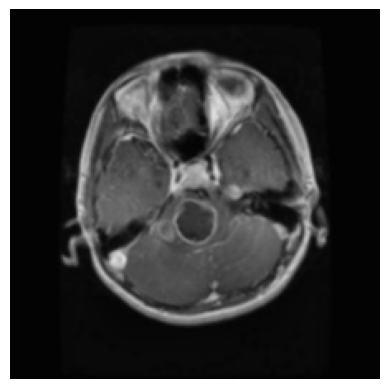

In [23]:
print("Pixel range:", X.min(), "\u2192", X.max())
plt.imshow(X[0])
plt.axis("off")
plt.show()

In [24]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.10, random_state=42, stratify=y_train_full
)

# Convert y -> one-hot
y_train_cat = to_categorical(y_train, num_classes=len(class_names))
y_val_cat   = to_categorical(y_val,   num_classes=len(class_names))
y_test_cat  = to_categorical(y_test,  num_classes=len(class_names))

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (2324, 224, 224, 3)
Validation: (259, 224, 224, 3)
Test: (287, 224, 224, 3)


In [25]:
# ---------------------------------------------------------------
# Data Augmentation — UNCHANGED as requested
# ---------------------------------------------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    brightness_range=[1.0, 1.2],
    fill_mode='nearest'
)

val_datagen  = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow(X_train, y_train_cat, batch_size=32, shuffle=True)
val_gen   = val_datagen.flow(X_val,   y_val_cat,   batch_size=32)
test_gen  = test_datagen.flow(X_test,  y_test_cat,  batch_size=32)

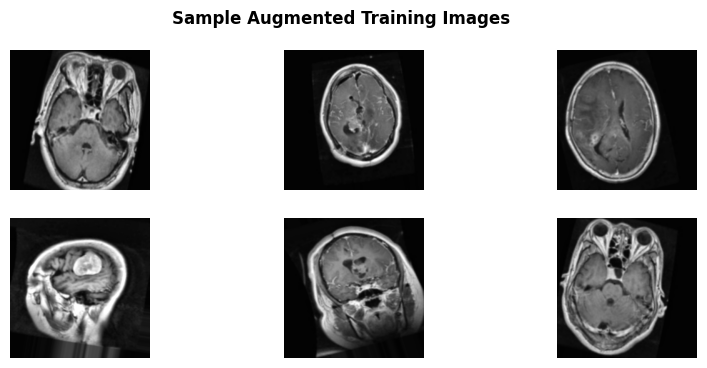

In [26]:
images, labels = next(train_gen)
plt.figure(figsize=(10, 4))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i])
    plt.axis("off")
plt.suptitle("Sample Augmented Training Images", fontweight='bold')
plt.show()

In [27]:
# ---------------------------------------------------------------
# EfficientNetB0 Model  (replaces ResNet50)
# NOTE: EfficientNetB0 includes its own internal rescaling so
# the 0-1 normalised inputs from ImageDataGenerator are correct.
# ---------------------------------------------------------------
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Phase-1: Freeze the entire base to warm-up the head first
base_model.trainable = False

print(f"Total layers in base model  : {len(base_model.layers)}")
print(f"Trainable layers (phase-1)  : {sum(1 for l in base_model.layers if l.trainable)}")

# Build the classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(512, activation="relu", kernel_regularizer='l2')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation="relu", kernel_regularizer='l2')(x)
x = Dropout(0.4)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(len(class_names), activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-3),   # Higher LR for frozen-base warm-up
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Total layers in base model  : 238
Trainable layers (phase-1)  : 0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,875,303 (18.60 MB)

 Trainable params: 823,172 (3.14 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [29]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

steps_per_epoch = len(X_train) // 32

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

checkpoint_path = "/content/drive/MyDrive/brain-tumor-classification/models/best_efficientnetb0_checkpoint.h5"
model_checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# ---------------------------------------------------------------
# Phase-1 Training  — warm up the head (10 epochs max)
# ---------------------------------------------------------------
print("\n===== Phase-1: Warm-up head (base frozen) =====")
history_phase1 = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=10,
    validation_data=val_gen,
    callbacks=[reduce_lr, early_stop, model_checkpoint]
)
print("Phase-1 completed!")


===== Phase-1: Warm-up head (base frozen) =====
Epoch 1/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.2879 - loss: 2.1533
Epoch 1: val_accuracy improved from None to 0.28958, saving model to /content/drive/MyDrive/brain-tumor-classification/models/best_efficientnetb0_checkpoint.h5



Epoch 1: finished saving model to /content/drive/MyDrive/brain-tumor-classification/models/best_efficientnetb0_checkpoint.h5
72/72 ━━━━━━━━━━━━━━━━━━━━ 35s 485ms/step - accuracy: 0.2866 - loss: 2.0657 - val_accuracy: 0.2896 - val_loss: 1.9066 - learning_rate: 0.0010
Epoch 2/10
 1/72 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.2812 - loss: 1.9058
Epoch 2: val_accuracy did not improve from 0.28958
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2812 - loss: 1.9058 - val_accuracy: 0.2896 - val_loss: 1.9032 - learning_rate: 0.0010
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.2719 - loss: 1.8414
Epoch 3: val_accuracy did not improve from 0.28958
72/72 ━━━━━━━━━━━━━━━━━━━━ 33s 454ms/step - accuracy: 0.2875 - loss: 1.7933 - val_accuracy: 0.2857 - val_loss: 1.7017 - learning_rate: 0.0010
Epoch 4/10
 1/72 ━━━━━━━━━━━━━━━━━━━━ 11s 165ms/step - accuracy: 0.3438 - loss: 1.6984
Epoch 4: val_accuracy did not improve from 0.28958
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step -

In [30]:
# ---------------------------------------------------------------
# Phase-2 Fine-tuning — unfreeze top layers of EfficientNetB0
# Unfreeze the last 30 layers for fine-tuning
# ---------------------------------------------------------------
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

print(f"Trainable layers (phase-2 fine-tune): {sum(1 for l in base_model.layers if l.trainable)}")

# Re-compile with a much lower learning rate for fine-tuning
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Reset callbacks (fresh patience counters)
reduce_lr_ft = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)
early_stop_ft = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)
model_checkpoint_ft = ModelCheckpoint(
    checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

print("\n===== Phase-2: Fine-tuning top layers =====")
history_phase2 = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=50,
    validation_data=val_gen,
    callbacks=[reduce_lr_ft, early_stop_ft, model_checkpoint_ft]
)

print("\nFine-tuning completed!")
print(f"Best model saved at: {checkpoint_path}")

Trainable layers (phase-2 fine-tune): 30

===== Phase-2: Fine-tuning top layers =====
Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 693ms/step - accuracy: 0.2975 - loss: 1.4427
Epoch 1: val_accuracy improved from None to 0.28571, saving model to /content/drive/MyDrive/brain-tumor-classification/models/best_efficientnetb0_checkpoint.h5



Epoch 1: finished saving model to /content/drive/MyDrive/brain-tumor-classification/models/best_efficientnetb0_checkpoint.h5
72/72 ━━━━━━━━━━━━━━━━━━━━ 103s 945ms/step - accuracy: 0.2871 - loss: 1.4303 - val_accuracy: 0.2857 - val_loss: 1.4139 - learning_rate: 1.0000e-04
Epoch 2/50
 1/72 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.4688 - loss: 1.3519
Epoch 2: val_accuracy did not improve from 0.28571
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4688 - loss: 1.3519 - val_accuracy: 0.2857 - val_loss: 1.4138 - learning_rate: 1.0000e-04
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.2632 - loss: 1.4142
Epoch 3: val_accuracy did not improve from 0.28571
72/72 ━━━━━━━━━━━━━━━━━━━━ 34s 465ms/step - accuracy: 0.2880 - loss: 1.4081 - val_accuracy: 0.2857 - val_loss: 1.4040 - learning_rate: 1.0000e-04
Epoch 4/50
 1/72 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.2500 - loss: 1.3887
Epoch 4: val_accuracy did not improve from 0.28571
72/72 ━━━━━━━━━━━━━━━━━━━━ 1


Epoch 11: finished saving model to /content/drive/MyDrive/brain-tumor-classification/models/best_efficientnetb0_checkpoint.h5
72/72 ━━━━━━━━━━━━━━━━━━━━ 43s 480ms/step - accuracy: 0.3233 - loss: 1.3651 - val_accuracy: 0.4247 - val_loss: 1.3679 - learning_rate: 1.0000e-04
Epoch 12/50
 1/72 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.2188 - loss: 1.3362
Epoch 12: val_accuracy did not improve from 0.42471
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2188 - loss: 1.3362 - val_accuracy: 0.3591 - val_loss: 1.3727 - learning_rate: 1.0000e-04
Epoch 13/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.3385 - loss: 1.3588
Epoch 13: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 13: val_accuracy did not improve from 0.42471
72/72 ━━━━━━━━━━━━━━━━━━━━ 39s 458ms/step - accuracy: 0.3464 - loss: 1.3483 - val_accuracy: 0.3436 - val_loss: 1.3839 - learning_rate: 1.0000e-04
Epoch 14/50
 1/72 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - accuracy: 0.5000 - loss: 1.3


Epoch 15: finished saving model to /content/drive/MyDrive/brain-tumor-classification/models/best_efficientnetb0_checkpoint.h5
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 488ms/step - accuracy: 0.3412 - loss: 1.3408 - val_accuracy: 0.4672 - val_loss: 1.2757 - learning_rate: 5.0000e-05
Epoch 16/50
 1/72 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.5000 - loss: 1.1951
Epoch 16: val_accuracy did not improve from 0.46718
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5000 - loss: 1.1951 - val_accuracy: 0.4672 - val_loss: 1.2708 - learning_rate: 5.0000e-05
Epoch 17/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - accuracy: 0.3782 - loss: 1.3176
Epoch 17: val_accuracy did not improve from 0.46718
72/72 ━━━━━━━━━━━━━━━━━━━━ 34s 469ms/step - accuracy: 0.3739 - loss: 1.3156 - val_accuracy: 0.3012 - val_loss: 1.3344 - learning_rate: 5.0000e-05
Epoch 18/50
 1/72 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.4062 - loss: 1.3886
Epoch 18: val_accuracy did not improve from 0.46718
72/72 ━━━━━━━━━━━━━━━━━


Epoch 25: finished saving model to /content/drive/MyDrive/brain-tumor-classification/models/best_efficientnetb0_checkpoint.h5
72/72 ━━━━━━━━━━━━━━━━━━━━ 34s 471ms/step - accuracy: 0.3787 - loss: 1.2860 - val_accuracy: 0.5135 - val_loss: 1.1792 - learning_rate: 1.2500e-05
Epoch 26/50
 1/72 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.4375 - loss: 1.2462
Epoch 26: val_accuracy improved from 0.51351 to 0.52124, saving model to /content/drive/MyDrive/brain-tumor-classification/models/best_efficientnetb0_checkpoint.h5



Epoch 26: finished saving model to /content/drive/MyDrive/brain-tumor-classification/models/best_efficientnetb0_checkpoint.h5
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.4375 - loss: 1.2462 - val_accuracy: 0.5212 - val_loss: 1.1785 - learning_rate: 1.2500e-05
Epoch 27/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.3761 - loss: 1.2984
Epoch 27: val_accuracy did not improve from 0.52124
72/72 ━━━━━━━━━━━━━━━━━━━━ 33s 456ms/step - accuracy: 0.3839 - loss: 1.2902 - val_accuracy: 0.4093 - val_loss: 1.2152 - learning_rate: 1.2500e-05
Epoch 28/50
 1/72 ━━━━━━━━━━━━━━━━━━━━ 21s 301ms/step - accuracy: 0.3438 - loss: 1.3029
Epoch 28: val_accuracy did not improve from 0.52124
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3438 - loss: 1.3029 - val_accuracy: 0.4054 - val_loss: 1.2166 - learning_rate: 1.2500e-05
Epoch 29/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.3777 - loss: 1.2817
Epoch 29: ReduceLROnPlateau reducing learning rate to 6.24999984211172e-06

In [31]:
loss, acc = model.evaluate(test_gen)
print("Test Accuracy:", acc)

# Accuracy guard
if acc < 0.80:
    print("WARNING: Accuracy is below 80%. Consider training for more epochs or adjusting hyperparameters.")
else:
    print(f"SUCCESS: Model achieved {acc*100:.2f}% accuracy (>= 80% target met).")

9/9 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.5401 - loss: 1.1778
Test Accuracy: 0.5400696992874146


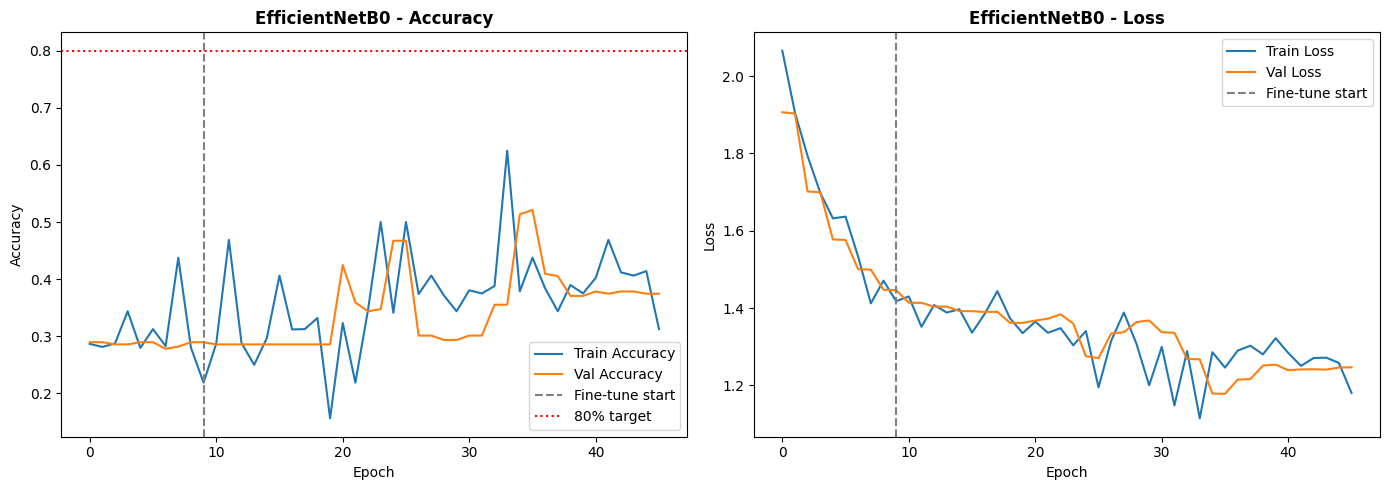

In [32]:
# Merge both training histories for plotting
def merge_histories(h1, h2):
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history[key]
    return merged

merged = merge_histories(history_phase1, history_phase2)
phase1_len = len(history_phase1.history['accuracy'])

plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(merged['accuracy'],     label='Train Accuracy')
plt.plot(merged['val_accuracy'], label='Val Accuracy')
plt.axvline(x=phase1_len - 1, color='gray', linestyle='--', label='Fine-tune start')
plt.axhline(y=0.80, color='red', linestyle=':', label='80% target')
plt.title('EfficientNetB0 - Accuracy', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(merged['loss'],     label='Train Loss')
plt.plot(merged['val_loss'], label='Val Loss')
plt.axvline(x=phase1_len - 1, color='gray', linestyle='--', label='Fine-tune start')
plt.title('EfficientNetB0 - Loss', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [33]:
model_save_path = "/content/drive/MyDrive/brain-tumor-classification/models/EfficientNetB0"
os.makedirs(model_save_path, exist_ok=True)

# Save as .pkl
model_file = os.path.join(model_save_path, "efficientnetb0_brain_tumor_model.pkl")
with open(model_file, 'wb') as f:
    pickle.dump(model, f)
print(f"Model saved as .pkl at: {model_file}")

# Save as .h5
h5_file = os.path.join(model_save_path, "efficientnetb0_brain_tumor_model.h5")
model.save(h5_file)
print(f"Model saved as .h5  at: {h5_file}")

# Save class names
class_names_file = os.path.join(model_save_path, "class_names.pkl")
with open(class_names_file, 'wb') as f:
    pickle.dump(class_names, f)
print(f"Class names saved   at: {class_names_file}")

Model saved as .pkl at: /content/drive/MyDrive/brain-tumor-classification/models/EfficientNetB0/efficientnetb0_brain_tumor_model.pkl
Model saved as .h5  at: /content/drive/MyDrive/brain-tumor-classification/models/EfficientNetB0/efficientnetb0_brain_tumor_model.h5
Class names saved   at: /content/drive/MyDrive/brain-tumor-classification/models/EfficientNetB0/class_names.pkl


In [34]:
X_test_normalized = X_test / 255.0   # Normalise same as test_gen
y_pred_probs = model.predict(X_test_normalized, batch_size=32, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test  # Original labels (not one-hot)

print("\nPredictions shape :", y_pred.shape)
print("True labels shape :", y_true.shape)
print("Sample predictions:", y_pred[:10])
print("Sample true labels:", y_true[:10])

9/9 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step

Predictions shape : (287,)
True labels shape : (287,)
Sample predictions: [0 0 0 0 0 3 0 0 0 3]
Sample true labels: [0 0 1 0 3 3 0 2 1 2]


In [35]:
print("\n" + "="*60)
print("OVERALL METRICS")
print("="*60)

overall_accuracy = accuracy_score(y_true, y_pred)
print(f"Overall Accuracy  : {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")
print(f"Keras Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print(f"Difference        : {abs(overall_accuracy - acc):.6f}")

overall_precision = precision_score(y_true, y_pred, average='weighted')
overall_recall    = recall_score(y_true, y_pred, average='weighted')
overall_f1        = f1_score(y_true, y_pred, average='weighted')

print(f"\nOverall Precision : {overall_precision:.4f}")
print(f"Overall Recall    : {overall_recall:.4f}")
print(f"Overall F1-Score  : {overall_f1:.4f}")

macro_precision = precision_score(y_true, y_pred, average='macro')
macro_recall    = recall_score(y_true, y_pred, average='macro')
macro_f1        = f1_score(y_true, y_pred, average='macro')

print(f"\nMacro Precision   : {macro_precision:.4f}")
print(f"Macro Recall      : {macro_recall:.4f}")
print(f"Macro F1-Score    : {macro_f1:.4f}")


OVERALL METRICS
Overall Accuracy  : 0.5401 (54.01%)
Keras Test Accuracy: 0.5401 (54.01%)
Difference        : 0.000000

Overall Precision : 0.5052
Overall Recall    : 0.5401
Overall F1-Score  : 0.4392

Macro Precision   : 0.4970
Macro Recall      : 0.4806
Macro F1-Score    : 0.4020


In [36]:
print("\n" + "="*60)
print("CLASSIFICATION REPORT (CLASS-WISE METRICS)")
print("="*60)
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)


CLASSIFICATION REPORT (CLASS-WISE METRICS)
                  precision    recall  f1-score   support

    glioma_tumor     0.5170    0.9157    0.6609        83
meningioma_tumor     0.4444    0.0488    0.0879        82
        no_tumor     0.4444    0.1026    0.1667        39
 pituitary_tumor     0.5820    0.8554    0.6927        83

        accuracy                         0.5401       287
       macro avg     0.4970    0.4806    0.4020       287
    weighted avg     0.5052    0.5401    0.4392       287



In [37]:
print("\n" + "="*60)
print("CLASS-WISE DETAILED METRICS")
print("="*60)

for i, class_name in enumerate(class_names):
    class_indices = np.where(y_true == i)[0]
    if len(class_indices) > 0:
        class_predictions = y_pred[class_indices]
        class_correct = np.sum(class_predictions == i)
        class_total   = len(class_indices)
        class_accuracy = class_correct / class_total

        tp = class_correct
        fp = np.sum(y_pred == i) - tp
        fn = class_total - tp

        class_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        class_recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
        class_f1        = 2 * (class_precision * class_recall) / (class_precision + class_recall) if (class_precision + class_recall) > 0 else 0

        print(f"\n{class_name}:")
        print(f"  Accuracy  : {class_accuracy:.4f} ({class_accuracy*100:.2f}%)")
        print(f"  Correct   : {class_correct}/{class_total}")
        print(f"  Precision : {class_precision:.4f}")
        print(f"  Recall    : {class_recall:.4f}")
        print(f"  F1-Score  : {class_f1:.4f}")
        print(f"  TP: {tp}, FP: {fp}, FN: {fn}")


CLASS-WISE DETAILED METRICS

glioma_tumor:
  Accuracy  : 0.9157 (91.57%)
  Correct   : 76/83
  Precision : 0.5170
  Recall    : 0.9157
  F1-Score  : 0.6609
  TP: 76, FP: 71, FN: 7

meningioma_tumor:
  Accuracy  : 0.0488 (4.88%)
  Correct   : 4/82
  Precision : 0.4444
  Recall    : 0.0488
  F1-Score  : 0.0879
  TP: 4, FP: 5, FN: 78

no_tumor:
  Accuracy  : 0.1026 (10.26%)
  Correct   : 4/39
  Precision : 0.4444
  Recall    : 0.1026
  F1-Score  : 0.1667
  TP: 4, FP: 5, FN: 35

pituitary_tumor:
  Accuracy  : 0.8554 (85.54%)
  Correct   : 71/83
  Precision : 0.5820
  Recall    : 0.8554
  F1-Score  : 0.6927
  TP: 71, FP: 51, FN: 12



CONFUSION MATRIX

Raw Confusion Matrix:
[[76  1  0  6]
 [55  4  5 18]
 [ 7  1  4 27]
 [ 9  3  0 71]]

Rows = True Labels, Columns = Predicted Labels


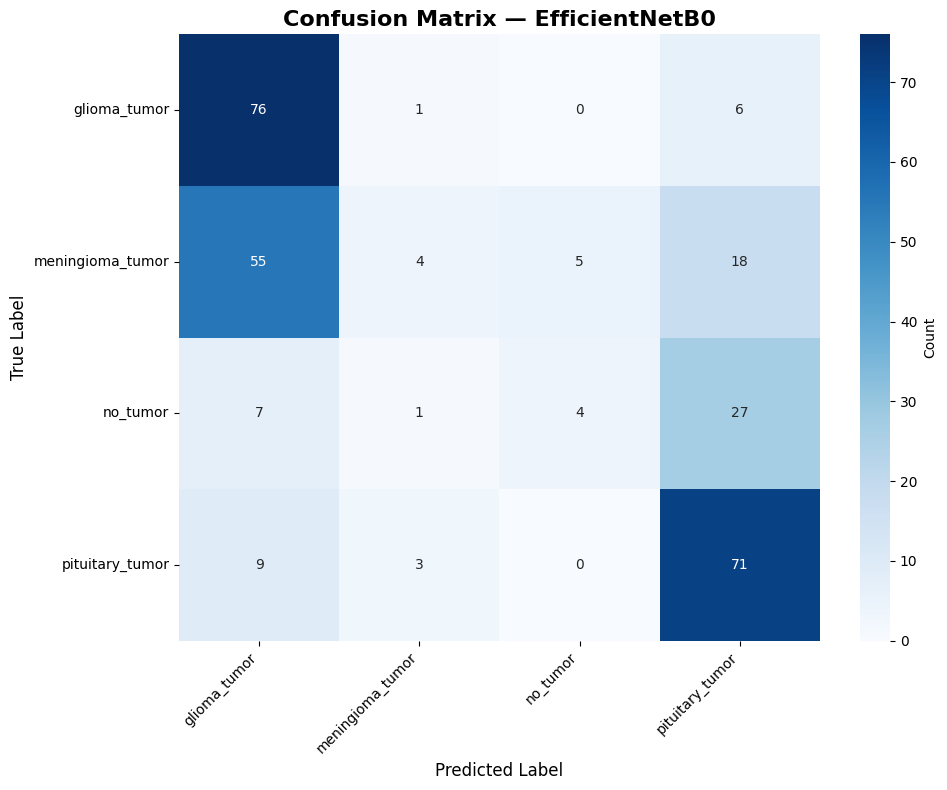

In [38]:
print("\n" + "="*60)
print("CONFUSION MATRIX")
print("="*60)

cm = confusion_matrix(y_true, y_pred)
print("\nRaw Confusion Matrix:")
print(cm)
print("\nRows = True Labels, Columns = Predicted Labels")

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix — EfficientNetB0', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Normalized Confusion Matrix (by row):
[[0.91566265 0.01204819 0.         0.07228916]
 [0.67073171 0.04878049 0.06097561 0.2195122 ]
 [0.17948718 0.02564103 0.1025641  0.69230769]
 [0.10843373 0.03614458 0.         0.85542169]]


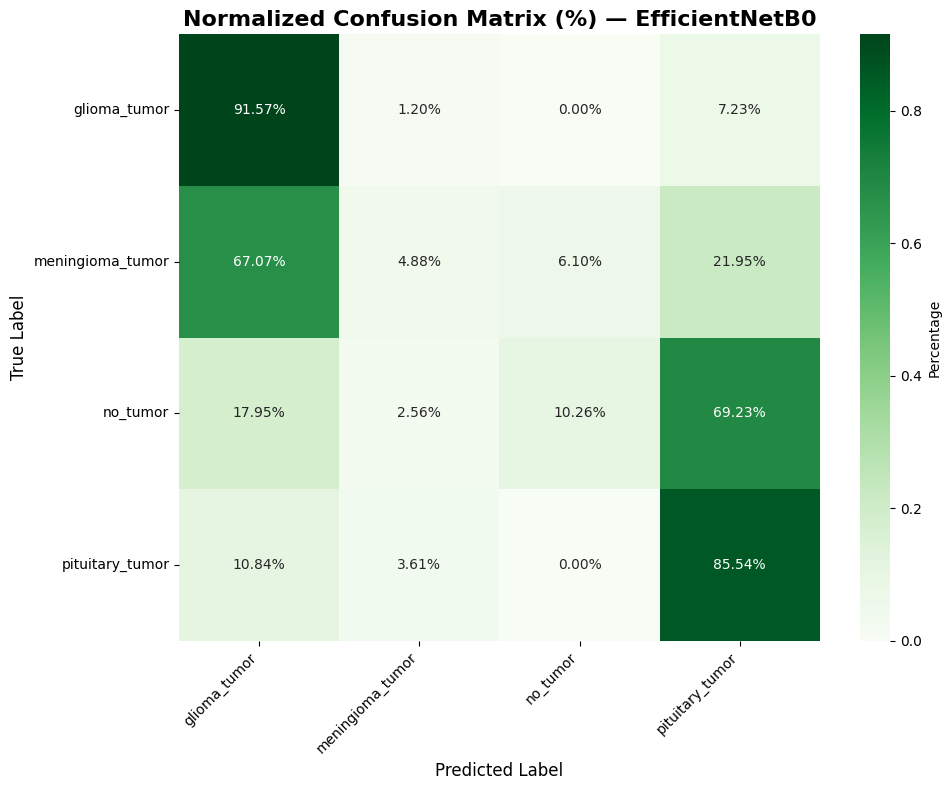

In [39]:
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

print("\nNormalized Confusion Matrix (by row):")
print(cm_normalized)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Percentage'})
plt.title('Normalized Confusion Matrix (%) — EfficientNetB0', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

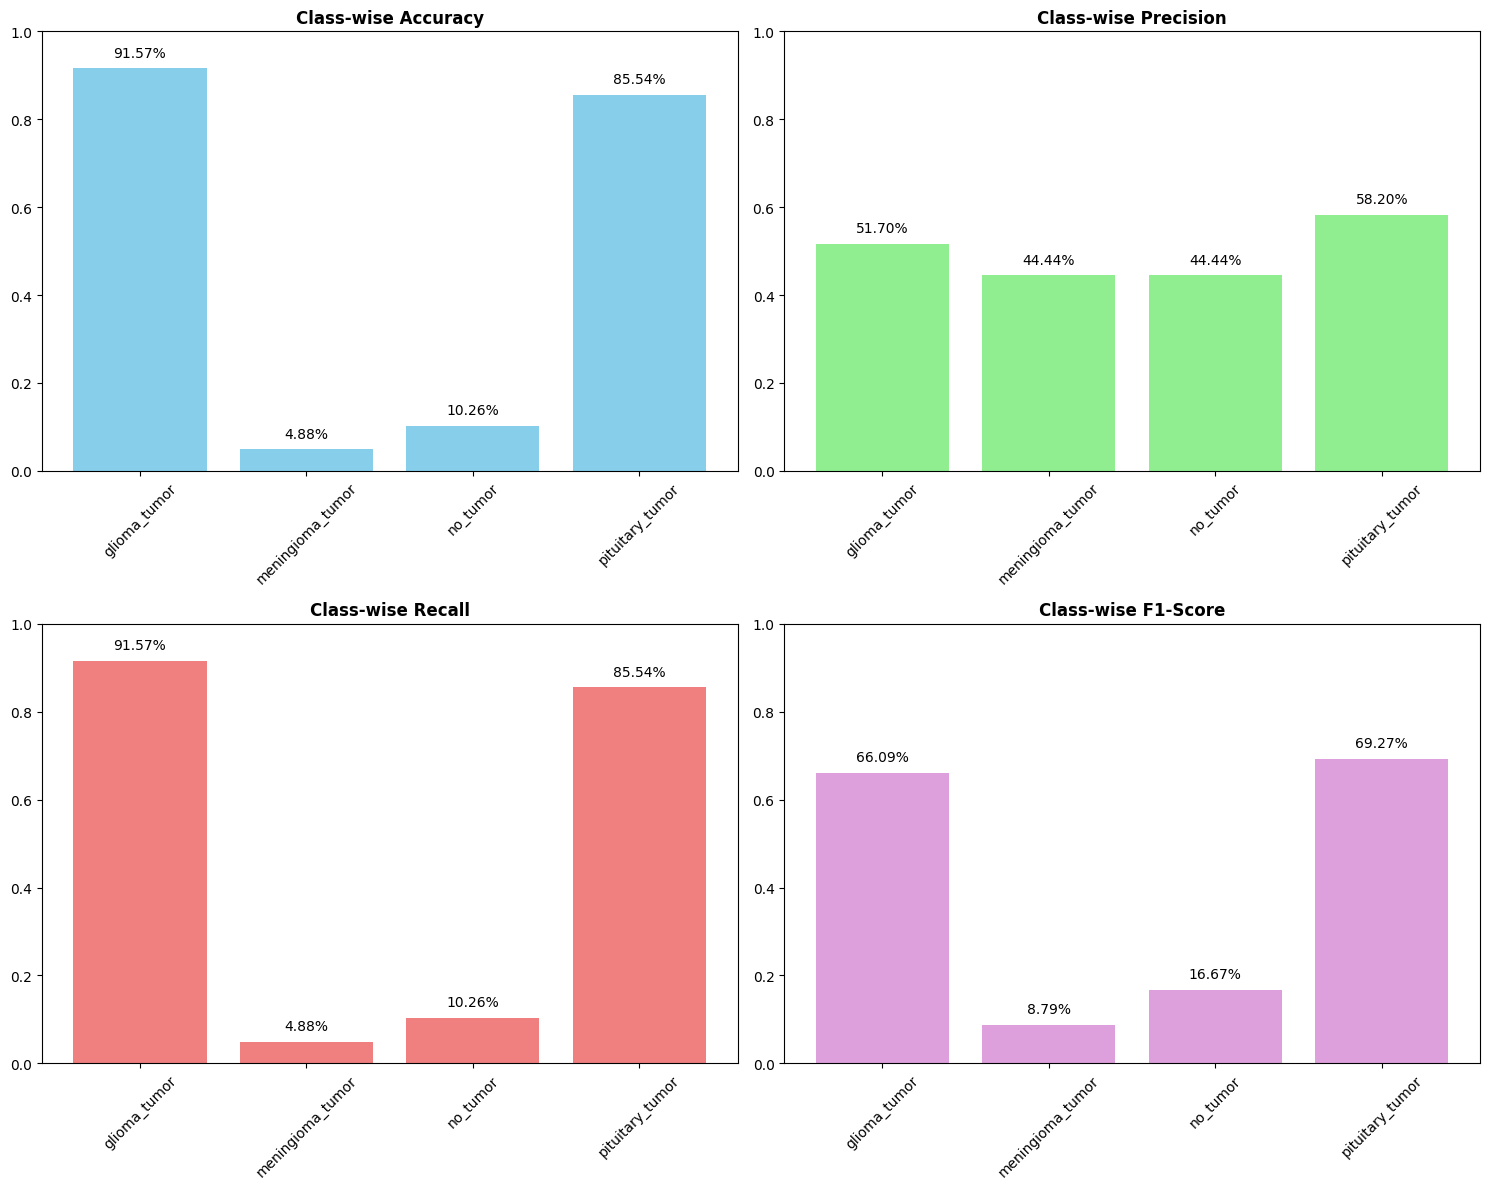

In [40]:
class_accuracies  = []
class_precisions  = []
class_recalls     = []
class_f1_scores   = []

for i in range(len(class_names)):
    class_indices = np.where(y_true == i)[0]
    if len(class_indices) > 0:
        class_predictions = y_pred[class_indices]
        class_acc = np.sum(class_predictions == i) / len(class_indices)

        tp = np.sum(class_predictions == i)
        fp = np.sum(y_pred == i) - tp
        fn = len(class_indices) - tp

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1        = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        class_accuracies.append(class_acc)
        class_precisions.append(precision)
        class_recalls.append(recall)
        class_f1_scores.append(f1)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

for ax, values, title, color in zip(
    axes.flatten(),
    [class_accuracies, class_precisions, class_recalls, class_f1_scores],
    ['Class-wise Accuracy', 'Class-wise Precision', 'Class-wise Recall', 'Class-wise F1-Score'],
    ['skyblue', 'lightgreen', 'lightcoral', 'plum']
):
    ax.bar(class_names, values, color=color)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=45)
    for j, v in enumerate(values):
        ax.text(j, v + 0.02, f'{v:.2%}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [41]:
metrics_file = os.path.join(model_save_path, "model_metrics.txt")
with open(metrics_file, 'w') as f:
    f.write("=" * 60 + "\n")
    f.write("BRAIN TUMOR CLASSIFICATION - EfficientNetB0 METRICS\n")
    f.write("=" * 60 + "\n\n")

    f.write("=" * 60 + "\n")
    f.write("OVERALL METRICS\n")
    f.write("=" * 60 + "\n")
    f.write(f"Overall Accuracy  : {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)\n")
    f.write(f"Keras Test Accuracy: {acc:.4f} ({acc*100:.2f}%)\n")
    f.write(f"Difference        : {abs(overall_accuracy - acc):.6f}\n\n")

    f.write(f"Weighted Precision: {overall_precision:.4f}\n")
    f.write(f"Weighted Recall   : {overall_recall:.4f}\n")
    f.write(f"Weighted F1-Score : {overall_f1:.4f}\n\n")

    f.write(f"Macro Precision   : {macro_precision:.4f}\n")
    f.write(f"Macro Recall      : {macro_recall:.4f}\n")
    f.write(f"Macro F1-Score    : {macro_f1:.4f}\n\n")

    f.write("=" * 60 + "\n")
    f.write("CLASSIFICATION REPORT\n")
    f.write("=" * 60 + "\n")
    f.write(report)
    f.write("\n")

    f.write("=" * 60 + "\n")
    f.write("CLASS-WISE DETAILED METRICS\n")
    f.write("=" * 60 + "\n")
    for i, class_name in enumerate(class_names):
        class_indices = np.where(y_true == i)[0]
        if len(class_indices) > 0:
            class_predictions = y_pred[class_indices]
            class_correct     = np.sum(class_predictions == i)
            class_total       = len(class_indices)
            class_accuracy    = class_correct / class_total

            tp = class_correct
            fp = np.sum(y_pred == i) - tp
            fn = class_total - tp

            class_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            class_recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
            class_f1        = 2 * (class_precision * class_recall) / (class_precision + class_recall) if (class_precision + class_recall) > 0 else 0

            f.write(f"\n{class_name}:\n")
            f.write(f"  Accuracy  : {class_accuracy:.4f} ({class_accuracy*100:.2f}%)\n")
            f.write(f"  Correct   : {class_correct}/{class_total}\n")
            f.write(f"  Precision : {class_precision:.4f}\n")
            f.write(f"  Recall    : {class_recall:.4f}\n")
            f.write(f"  F1-Score  : {class_f1:.4f}\n")
            f.write(f"  TP: {tp}, FP: {fp}, FN: {fn}\n")

    f.write("\n=" * 60 + "\n")
    f.write("CONFUSION MATRIX\n")
    f.write("=" * 60 + "\n")
    f.write("Rows = True Labels, Columns = Predicted Labels\n\n")
    f.write(str(cm))
    f.write("\n\nNormalized Confusion Matrix:\n")
    f.write(str(cm_normalized))

print(f"\nAll metrics saved to: {metrics_file}")


All metrics saved to: /content/drive/MyDrive/brain-tumor-classification/models/EfficientNetB0/model_metrics.txt


In [42]:
print("\n" + "="*60)
print("LOADING SAVED MODEL AND MAKING PREDICTIONS")
print("="*60)

with open(model_file, 'rb') as f:
    loaded_model = pickle.load(f)
print("Model loaded successfully!")

with open(class_names_file, 'rb') as f:
    loaded_class_names = pickle.load(f)
print("Class names loaded:", loaded_class_names)


LOADING SAVED MODEL AND MAKING PREDICTIONS
Model loaded successfully!
Class names loaded: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 40 variables whereas the saved optimizer has 78 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [43]:
def predict_image(model, img_array, class_names):
    """
    Predict the class of a single image.

    Args:
        model       : Trained Keras model
        img_array   : Image array (already resized to IMG_SIZE x IMG_SIZE)
        class_names : List of class name strings

    Returns:
        predicted_class (str), confidence (float), all_probabilities (ndarray)
    """
    if img_array.max() > 1.0:
        img_array = img_array / 255.0

    img_array = np.expand_dims(img_array, axis=0)  # add batch dim

    predictions = model.predict(img_array, verbose=0)
    predicted_class_idx = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class_idx]

    return class_names[predicted_class_idx], confidence, predictions[0]

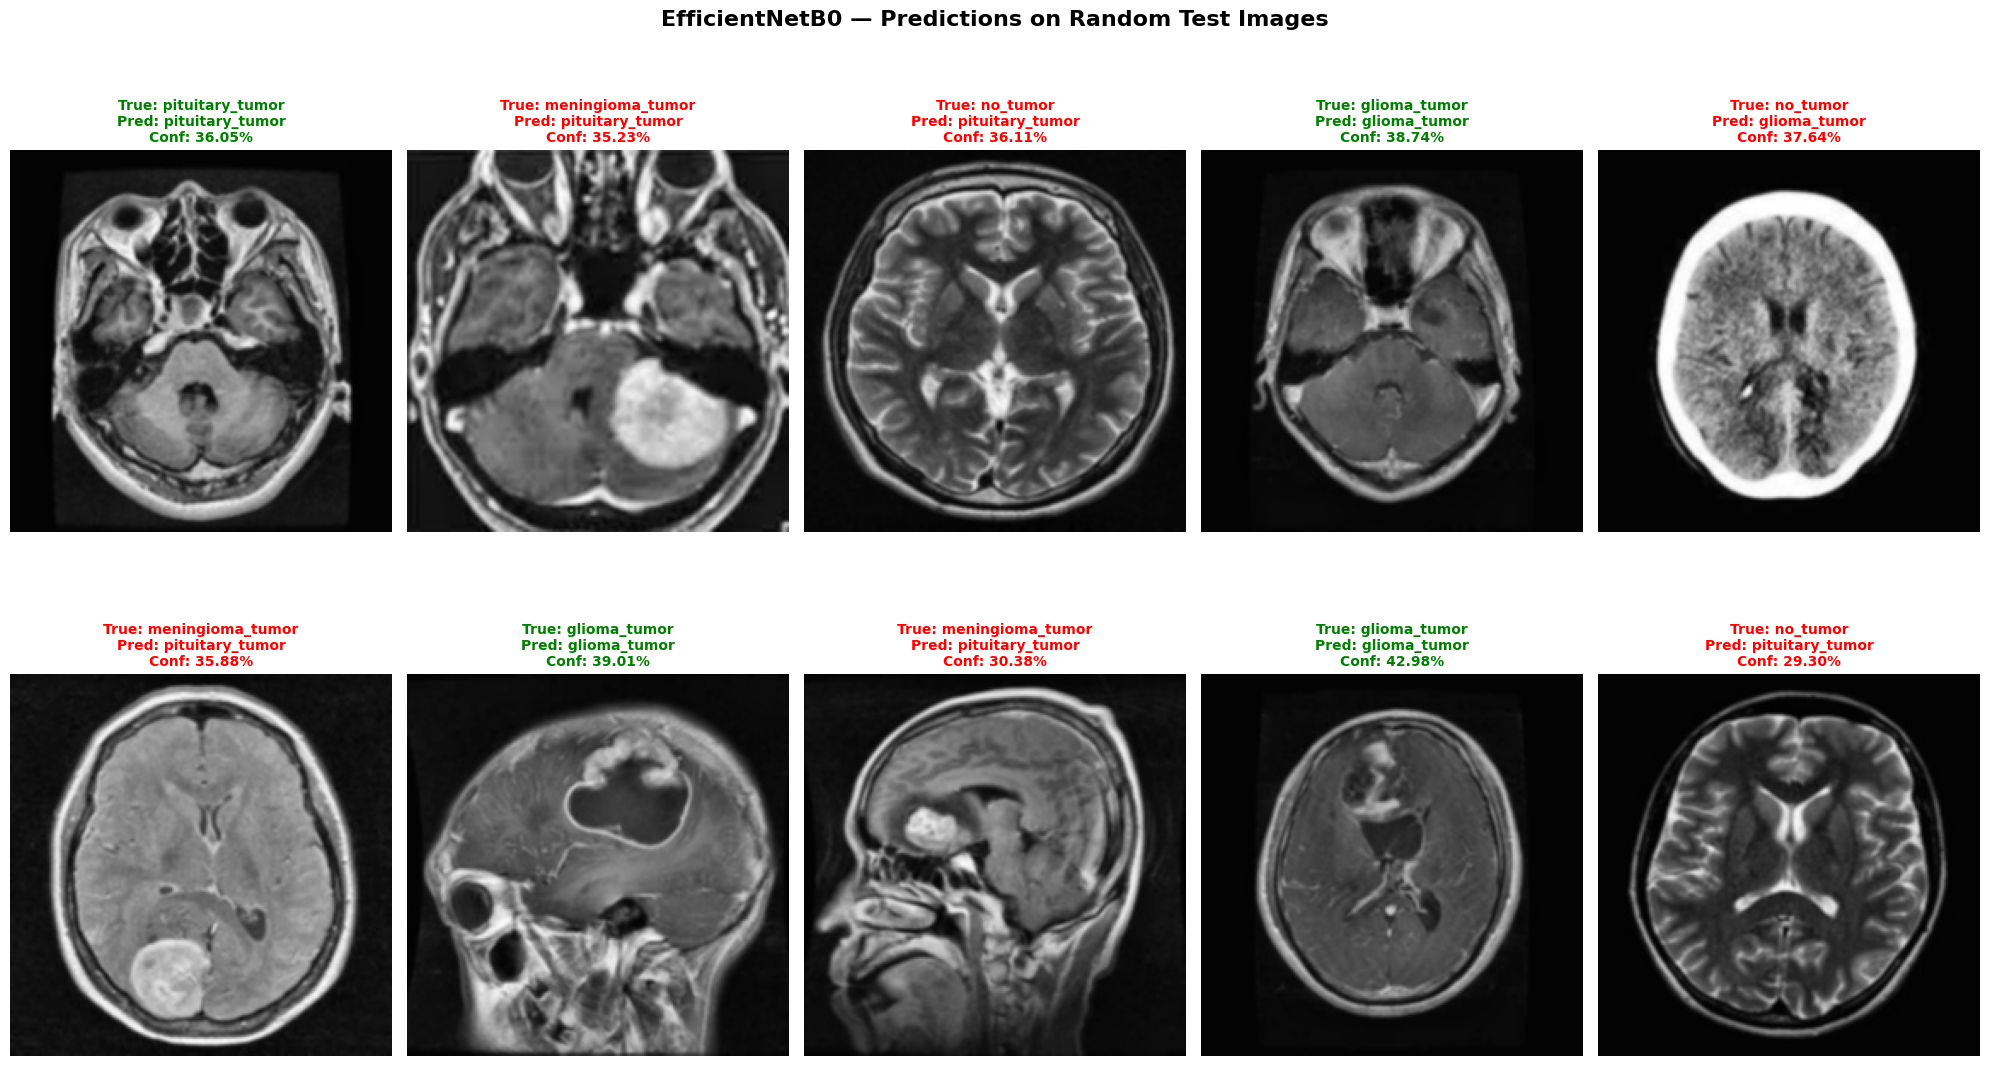

In [44]:
num_samples = 10
random_indices = np.random.choice(len(X_test), num_samples, replace=False)

plt.figure(figsize=(20, 12))
for idx, i in enumerate(random_indices):
    img = X_test[i]
    true_label = class_names[y_test[i]]

    pred_class, confidence, all_probs = predict_image(loaded_model, img, loaded_class_names)

    plt.subplot(2, 5, idx + 1)
    plt.imshow(img)
    plt.axis('off')

    color = 'green' if pred_class == true_label else 'red'
    plt.title(
        f'True: {true_label}\nPred: {pred_class}\nConf: {confidence:.2%}',
        fontsize=10, color=color, fontweight='bold'
    )

plt.suptitle('EfficientNetB0 — Predictions on Random Test Images',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()